# OPTIMAL (TANGENCY) PORTFOLIO  

In [1]:
from matplotlib import pyplot as plt
import numpy as np
#import scipy

In [2]:
#number of assets
N = 20
#number of days
T = 2000

#expected returns for all the assets
mu = np.random.uniform(0.0003, 0.0008, N)

#volatilities for all the assets
sigma = np.random.uniform(0.012, 0.02, N)



In [3]:
#time series data for all N assets over T days

returns = np.random.normal(
    loc=mu[:, None],
    scale=sigma[:, None],
    size=(N, T)
)

In [4]:

#compute moving returns and covariances
#window 
W = 1000

T_eff = T - W + 1

mu_roll = np.zeros((T_eff, N))
cov_roll = np.zeros((T_eff, N, N))

for i in range(0,T_eff):
    window = returns[:, i:i+W]

    mu_roll[i] = window.mean(axis=1)
    cov_roll[i] = np.cov(window, bias=False)



In [ ]:
len(mu_roll) #helpful to know the length of rolling retuns and covariances

1001

In [6]:

M = 5000   # number of portfolios per time slice

#no shorting allowed
weights = np.random.dirichlet(
    alpha=np.ones(N),
    size=M
)


In [ ]:
np.sum(weights, axis = 1) #check that all the weights add to 1 for each configuration

array([1., 1., 1., ..., 1., 1., 1.])

In [ ]:

# add one-hot vectors for checking the correctness of the plots
#one_hot = np.eye(N)  # shape (N,N)

#weights = np.vstack([weights, one_hot])  # shape (M+N, N)

In [8]:
#risk-free rate

#annual rate/number of trading days = daily return

r_f = 0.02/252

Equation of Capital Market Line (CML):

$ R_{\Pi} = R_0 + \frac{R - R_0}{\sigma} \sigma_{\Pi} $

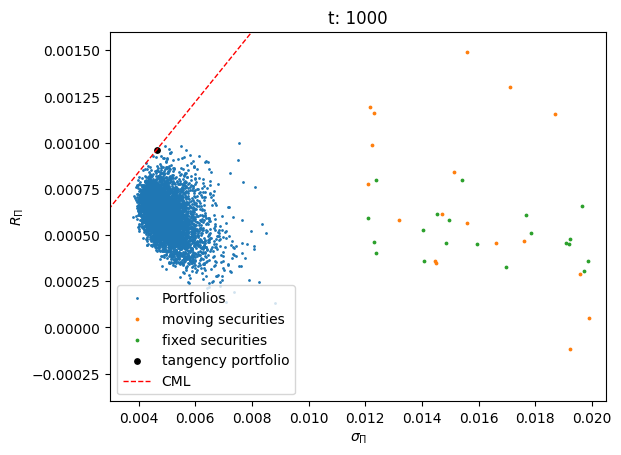

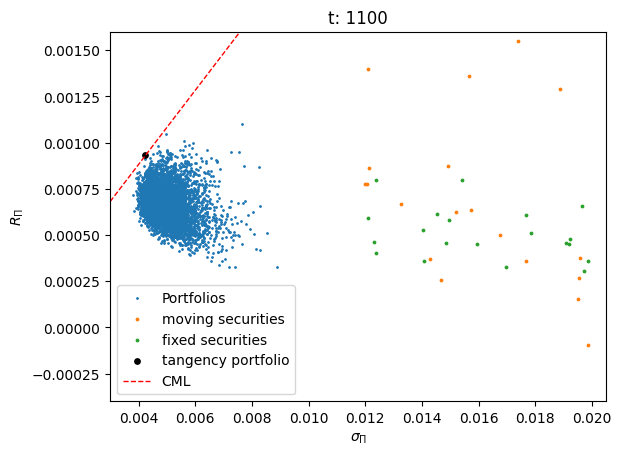

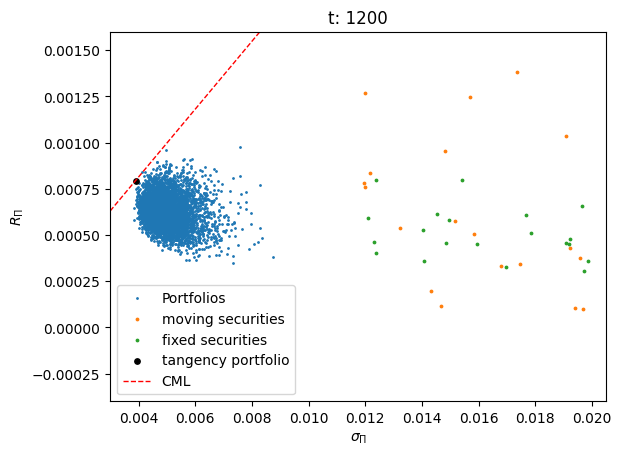

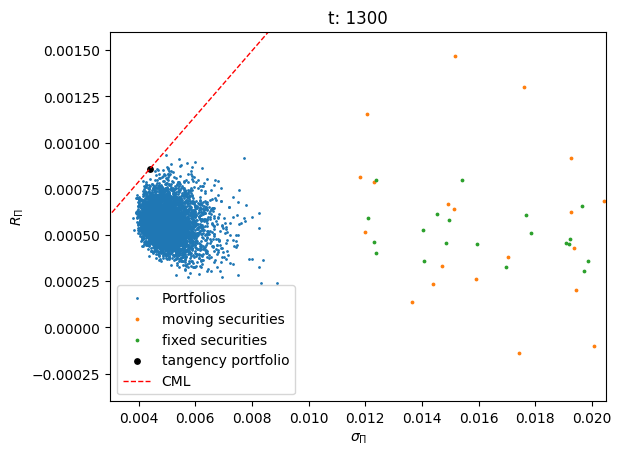

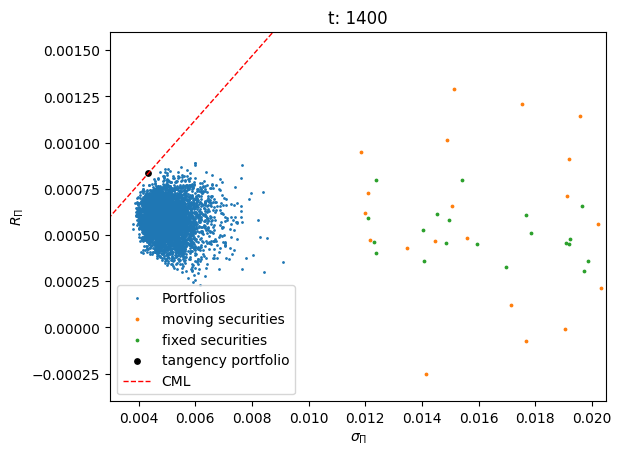

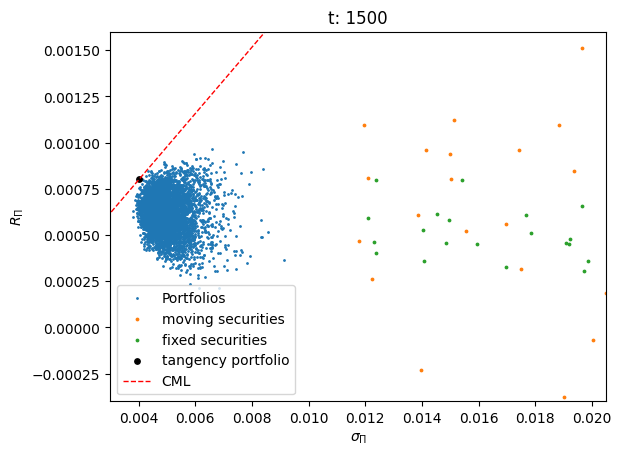

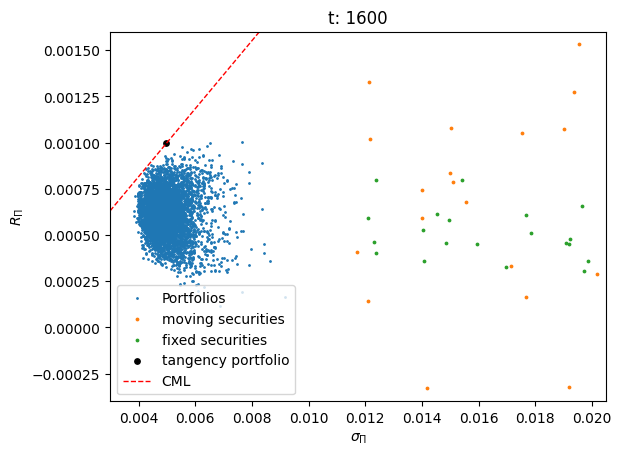

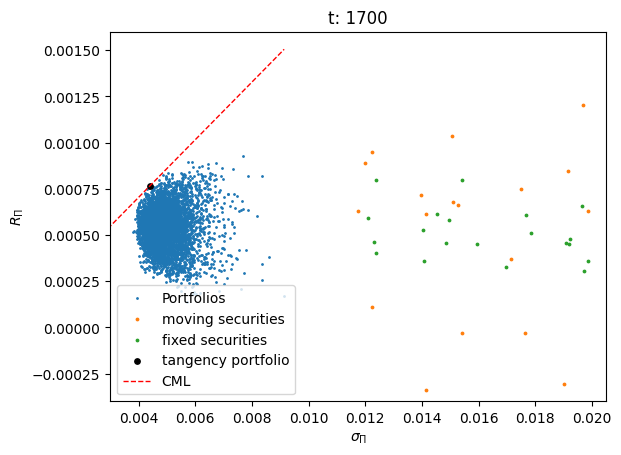

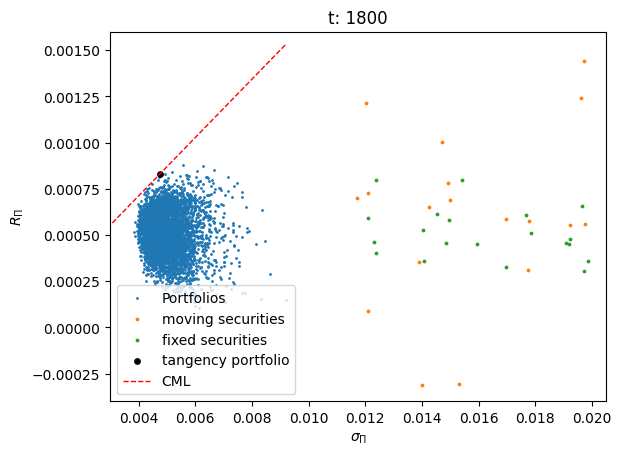

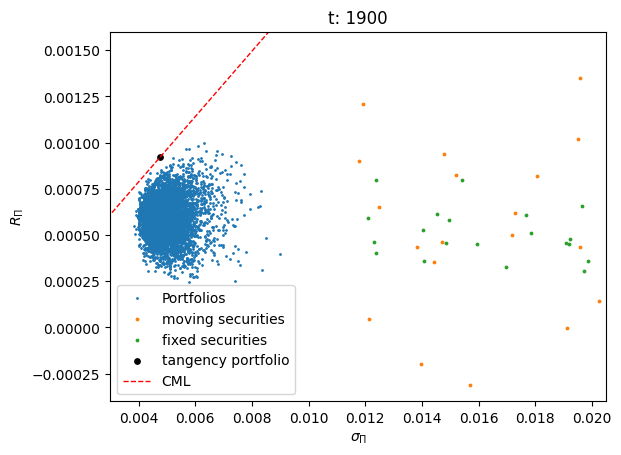

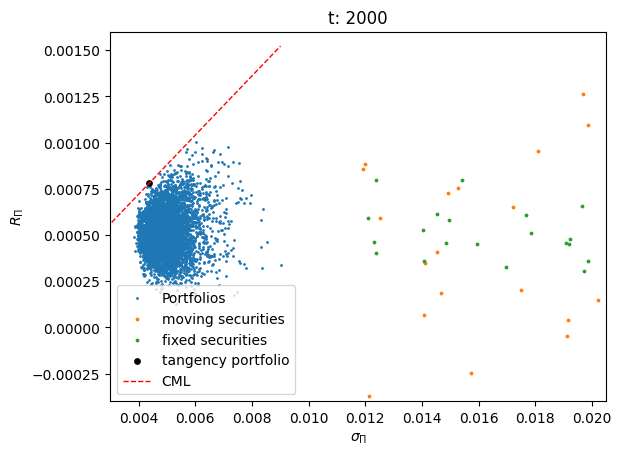

In [9]:

#calculate returns and risks at each time slice over weight space

for i in range(0,T_eff):

    #averages and covariance matrices at time t for individual assets
    mu_t = mu_roll[i]
    cov_t = cov_roll[i]
    sigma_t = np.sqrt(np.diagonal(cov_t))

    #all M returns over weight space
    port_mu = weights @ mu_t

    #all M volatilities over weight space
    port_var = np.einsum('ij,jk,ik->i', weights, cov_t, weights)
    port_sigma = np.sqrt(port_var)
    
    #CML
    #sharpe ratio
    sharpe = (port_mu - r_f) / port_sigma
    idx = np.argmax(sharpe)

    #tangency portfolio
    mu_T = port_mu[idx]
    sigma_T = port_sigma[idx]


    sigma_line = np.linspace(0, port_sigma.max(), 200)
    cml = r_f + (mu_T - r_f) / sigma_T * sigma_line

    
    if i%100 == 0:
        
        plt.scatter(port_sigma, port_mu, label ='Portfolios', s= 1)
        plt.scatter(sigma_t, mu_t, label ='moving securities', s=3)
        plt.scatter(sigma, mu, label ='fixed securities',s=3)
        plt.scatter(sigma_T, mu_T, s=15, c='black', label ='tangency portfolio')
        plt.plot(sigma_line, cml, c= 'red', label ='CML', linestyle='dashed', linewidth=1)
        
        plt.title('t: '+str(i + W))
        plt.legend(loc=3)
        plt.xlabel(r'$\sigma_\Pi$')
        plt.ylabel(r'$R_{\Pi}$')
        plt.xlim([0.003, 0.0205])
        plt.ylim([-0.0004, 0.0016])
        plt.show()



## Security Market Line

Equation of Security Market Line (SML):

$ R_i = R_0 + (R_T - R_0)\frac{\sigma^2(R_i,R_T)}{\sigma_T^2} $

In [15]:

def sml_check(i):
    #averages and covariance matrices at time t
    mu_t = mu_roll[i]
    cov_t = cov_roll[i]
    #sigma_t = np.sqrt(np.diagonal(cov_t))

    #all M returns over weight space
    port_mu = weights @ mu_t

    #all M risks over weight space
    port_var = np.einsum('ij,jk,ik->i', weights, cov_t, weights)
    port_sigma = np.sqrt(port_var)

    #sharpe ratio and identify tangency portfolio
    sharpe = (port_mu - r_f) / port_sigma
    idx = np.argmax(sharpe)
    mu_T = port_mu[idx]
    sigma_T = port_sigma[idx]
    weights_T = weights[idx,:]

    #SML
    sml_var = weights_T @ cov_t
    
    mu_sml = r_f + (mu_T - r_f)*( sml_var/sigma_T**2)

    plt.scatter(mu_t, mu_sml)
    plt.plot(mu_t, mu_t, label =r'$y=x$', c='black')
    plt.legend(loc=2)
    plt.xlabel(r'$\mu_t$')
    plt.ylabel(r'$\mu_{SML}$')
    plt.show()
    
    
    

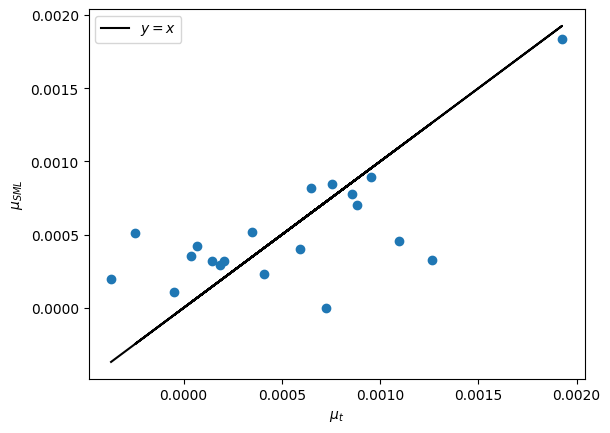

In [20]:
sml_check(1000)

## Movie of Optimal Portfolio

In [10]:
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import PillowWriter

In [13]:
def make_movie():
    metadata = dict(title='Movie', artist ='ayush_roy')
    writer = FFMpegWriter(fps=10, metadata = metadata)

    # Create the figure and subplots
    fig = plt.figure()

    # First row: Single subplot spanning both columns
    ax = plt.subplot()

    path = 'portfolio.mp4'



    with writer.saving(fig, path,100):
        for i in range(0,T_eff):

            #averages and covariance matrices at time t
            mu_t = mu_roll[i]
            cov_t = cov_roll[i]
            sigma_t = np.sqrt(np.diagonal(cov_t))

            #all M returns over weight space
            port_mu = weights @ mu_t

            #all M risks over weight space
            port_var = np.einsum('ij,jk,ik->i', weights, cov_t, weights)
            port_sigma = np.sqrt(port_var)
            
            #CML
            #sharpe ratio
            sharpe = (port_mu - r_f) / port_sigma
            idx = np.argmax(sharpe)

            #tangency portfolio
            mu_T = port_mu[idx]
            sigma_T = port_sigma[idx]


            sigma_line = np.linspace(0, port_sigma.max(), 200)
            cml = r_f + (mu_T - r_f) / sigma_T * sigma_line

            if i%4 == 0:
                ax.scatter(port_sigma, port_mu, label ='portfolios', s= 1)
                ax.scatter(sigma_t, mu_t, label ='moving securities', s=3)
                ax.scatter(sigma, mu, label ='fixed securities',s=3)
                ax.scatter(sigma_T, mu_T, s=15, c='black', label ='tangency portfolio')
                ax.plot(sigma_line, cml, c= 'red', label ='CML', linestyle='dashed', linewidth=1)
                
                ax.set_title('t: '+str(i + W))
                ax.legend(loc=2)
                ax.set_xlabel(r'$\sigma_\Pi$')
                ax.set_ylabel(r'$R_{\Pi}$')
                ax.set_xlim([0.003, 0.0205])
                ax.set_ylim([-0.0005, 0.002])
                writer.grab_frame()
                ax.cla()

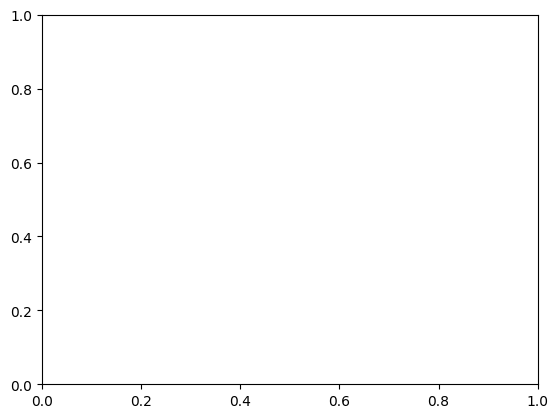

In [14]:
make_movie()